# 07 — Local Backtest (Sanity Check)

A **fast, free sanity check** before spending a Brain simulation slot.

Brain simulations take 2–5 minutes and consume quota. This notebook runs in
under 2 minutes using yfinance data and answers:

1. Does the signal have statistically significant IC? (t-stat > 2)
2. Does a long-top/short-bottom portfolio produce positive Sharpe? (> 0.5)
3. What is the expected turnover?

## Interpretation

| Metric | Green | Yellow | Red |
|--------|-------|--------|-----|
| IC t-stat | > 2 | 1–2 | < 1 |
| L/S Sharpe (annualised) | > 0.8 | 0.5–0.8 | < 0.5 |
| Turnover | < 0.5 | 0.5–0.8 | > 0.8 |

**Rule of thumb:** if `ic_tstat < 1.5` → don't bother submitting to Brain.

## Limitations

- We use S&P 500 close prices as a proxy — Brain has cleaner, more comprehensive data
- Transaction costs are ignored (Brain penalises high turnover via the fitness formula)
- This is a directional check, not a precise Brain score prediction

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from wq.utils import local_signal_test
from wq.alpha import AlphaConfig, compute_fitness

## Configuration

Set the alpha expression you want to test. You can load one from notebook 06
or define one manually.

In [2]:
import json

# Option A: load the last discovered alpha from notebook 06
discovered_path = repo_root / 'alphas' / 'discovered.json'
if discovered_path.exists():
    discovered = json.loads(discovered_path.read_text())
    ALPHA_EXPRESSION = discovered['expression']
    ALPHA_NOTES      = discovered.get('notes', '')
    print(f'Loaded from notebook 06: {ALPHA_EXPRESSION}')
else:
    # Option B: define manually
    ALPHA_EXPRESSION = 'ts_rank(close, 20)'   # change this
    ALPHA_NOTES      = 'Manual definition'
    print(f'Using manual definition: {ALPHA_EXPRESSION}')

# Lookback window for the signal (in days)
WINDOW        = 10
FORWARD_DAYS  = 5    # how many days ahead we predict

Loaded from notebook 06: ts_std_dev(returns, 5)


## Fetch market data

In [3]:
TICKERS = [
    'AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'META', 'TSLA', 'BRK-B', 'LLY', 'AVGO',
    'WMT', 'JPM', 'V', 'MA', 'UNH', 'XOM', 'PG', 'HD', 'COST', 'JNJ',
    'ORCL', 'BAC', 'ABBV', 'CRM', 'AMD', 'CVX', 'MRK', 'PEP', 'KO', 'ADBE',
    'NFLX', 'TMO', 'ACN', 'WFC', 'CSCO', 'LIN', 'DHR', 'ABT', 'MCD', 'QCOM',
    'GE', 'IBM', 'AMAT', 'TXN', 'INTU', 'NOW', 'AMGN', 'BKNG', 'ISRG', 'RTX',
]

data = yf.download(TICKERS, start='2018-01-01', end='2024-12-31',
                   progress=True, auto_adjust=True)

close   = data['Close'].dropna(how='all')
volume  = data['Volume'].dropna(how='all')
returns = close.pct_change().dropna(how='all')

print(f'Universe: {len(close.columns)} stocks, {len(close)} days')

[*********************100%***********************]  50 of 50 completed

Universe: 50 stocks, 1760 days


## Compute the signal

We translate common Brain expressions to pandas equivalents.
Add more mappings below as needed.

In [4]:
def brain_to_pandas(expression: str, close: pd.DataFrame, volume: pd.DataFrame,
                    returns: pd.DataFrame, window: int = 10) -> pd.DataFrame:
    """
    Approximate common Brain expressions using pandas.
    Not exact — Brain handles universe membership, survivorship, and NaN
    differently — but directionally correct for sanity checking.
    """
    expr = expression.strip().lower().replace(' ', '')

    # ts_rank(field, n)
    if expr.startswith('ts_rank(close'):
        w = int(expr.split(',')[1].replace(')', '').strip()) if ',' in expr else window
        return close.rolling(w).apply(lambda x: (x.rank().iloc[-1]-1)/(len(x)-1), raw=False)

    if expr.startswith('ts_rank(volume'):
        w = int(expr.split(',')[1].replace(')', '').strip()) if ',' in expr else window
        return volume.rolling(w).apply(lambda x: (x.rank().iloc[-1]-1)/(len(x)-1), raw=False)

    if expr.startswith('ts_rank(returns'):
        w = int(expr.split(',')[1].replace(')', '').strip()) if ',' in expr else window
        return returns.rolling(w).apply(lambda x: (x.rank().iloc[-1]-1)/(len(x)-1), raw=False)

    # ts_zscore(field, n)
    if expr.startswith('ts_zscore(close'):
        w = int(expr.split(',')[1].replace(')', '').strip()) if ',' in expr else window
        mu = close.rolling(w).mean()
        sigma = close.rolling(w).std()
        return (close - mu) / (sigma + 1e-10)

    if expr.startswith('ts_zscore(returns'):
        w = int(expr.split(',')[1].replace(')', '').strip()) if ',' in expr else window
        mu = returns.rolling(w).mean()
        sigma = returns.rolling(w).std()
        return (returns - mu) / (sigma + 1e-10)

    # -1 * ts_zscore (reversion)
    if expr.startswith('-1*ts_zscore(close') or expr.startswith('-ts_zscore(close'):
        w = int(expr.split(',')[1].replace(')', '').strip()) if ',' in expr else window
        mu = close.rolling(w).mean()
        sigma = close.rolling(w).std()
        return -1 * (close - mu) / (sigma + 1e-10)

    # -1 * ts_rank (reversion)
    if expr.startswith('-1*ts_rank(close') or expr.startswith('-ts_rank(close'):
        w = int(expr.split(',')[1].replace(')', '').strip()) if ',' in expr else window
        return -1 * close.rolling(w).apply(lambda x: (x.rank().iloc[-1]-1)/(len(x)-1), raw=False)

    # Default: n-day return (momentum proxy)
    print(f'Unknown expression pattern: {expression}. Falling back to {window}-day momentum.')
    return close.pct_change(window)


signal = brain_to_pandas(ALPHA_EXPRESSION, close, volume, returns, window=WINDOW)
print(f'Signal computed. Shape: {signal.shape}, non-null cells: {signal.notna().sum().sum():,}')

Unknown expression pattern: ts_std_dev(returns, 5). Falling back to 10-day momentum.
Signal computed. Shape: (1760, 50), non-null cells: 87,500


## Run the signal test

In [5]:
common_dates = signal.index.intersection(returns.index)
results = local_signal_test(
    signal.loc[common_dates],
    returns.loc[common_dates],
    forward_days=FORWARD_DAYS,
)

print(f'=== Local Backtest: {ALPHA_EXPRESSION} ===')
print(f'Notes: {ALPHA_NOTES}')
print()

THRESHOLDS = {
    'mean_ic':   (0.02,  0.01),
    'ic_tstat':  (2.0,   1.5),
    'ic_ir':     (0.5,   0.3),
    'turnover':  (0.5,   0.8),   # lower is better for turnover
    'ls_sharpe': (0.8,   0.5),
}

for metric, value in results.items():
    if metric == 'verdict':
        continue
    if metric in THRESHOLDS:
        hi, lo = THRESHOLDS[metric]
        if metric == 'turnover':
            flag = 'GREEN' if value < lo else ('YELLOW' if value < hi else 'RED')
        else:
            flag = 'GREEN' if value > hi else ('YELLOW' if value > lo else 'RED')
        print(f'  {metric:15s}: {value:>8}   [{flag}]')
    else:
        print(f'  {metric:15s}: {value:>8}')

print()
verdict = results['verdict']
print(f'VERDICT: {verdict}')
if verdict == 'SUBMIT':
    print('  → Signal passed sanity checks. Submit to Brain via notebook 02 or 03.')
else:
    print('  → Signal is weak. Try adjusting the expression, window, or direction before submitting.')

=== Local Backtest: ts_std_dev(returns, 5) ===
Notes: Discovered via RF feature importance: vol_5 was top predictor

  mean_ic        :  -0.0004   [RED]
  ic_std         :   0.2698
  ic_tstat       :    -0.06   [RED]
  ic_ir          :   -0.001   [RED]
  turnover       :      0.3   [GREEN]
  ls_sharpe      :    -0.21   [RED]

VERDICT: SKIP
  → Signal is weak. Try adjusting the expression, window, or direction before submitting.


## Long/short cumulative return

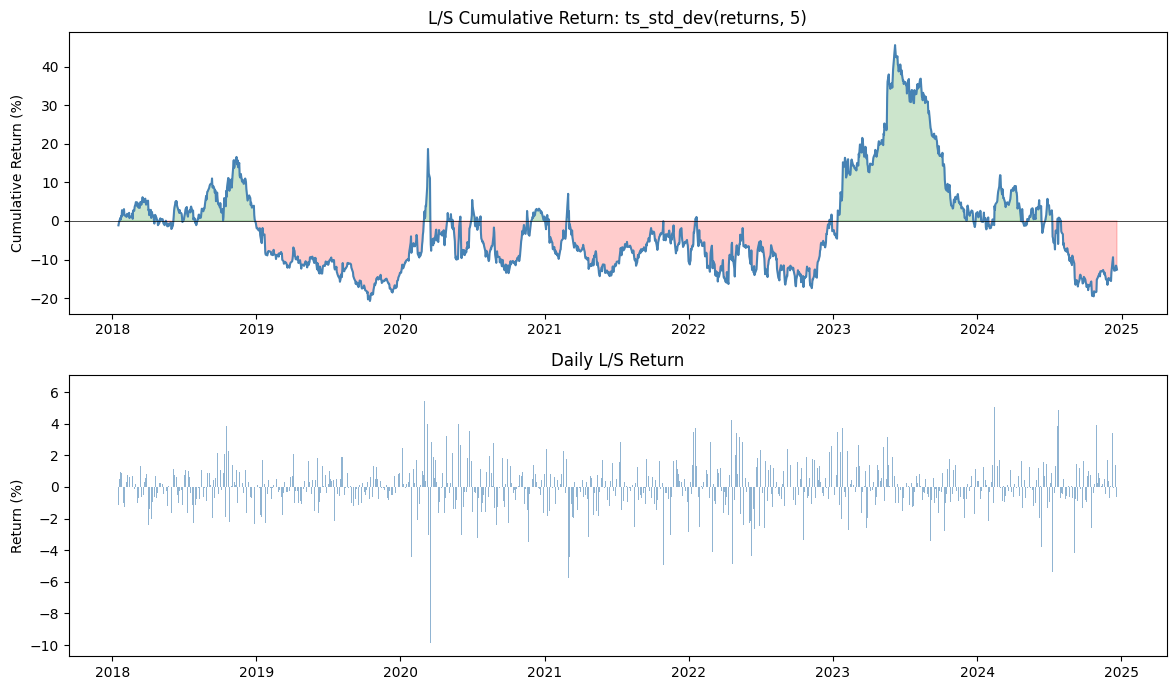


Total L/S return: -12.6%
Annualised Sharpe: -0.21


In [6]:
# Compute daily L/S returns for the equity curve
fwd_ret = returns.shift(-FORWARD_DAYS)
ls_daily = []

for date in signal.index[:-FORWARD_DAYS]:
    if date not in fwd_ret.index:
        continue
    r = fwd_ret.loc[date].dropna()
    s = signal.loc[date].dropna()
    common = r.index.intersection(s.index)
    if len(common) < 10:
        continue
    rank_pct = s[common].rank(pct=True)
    long_r  = r[common][rank_pct > 0.8].mean()
    short_r = r[common][rank_pct < 0.2].mean()
    ls_daily.append({'date': date, 'ls_return': long_r - short_r})

ls_df = pd.DataFrame(ls_daily).set_index('date')
cum_ret = (1 + ls_df['ls_return']).cumprod() - 1

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(cum_ret.index, cum_ret.values * 100, color='steelblue', lw=1.5)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].fill_between(cum_ret.index, cum_ret.values * 100, 0,
                     where=cum_ret.values > 0, alpha=0.2, color='green')
axes[0].fill_between(cum_ret.index, cum_ret.values * 100, 0,
                     where=cum_ret.values < 0, alpha=0.2, color='red')
axes[0].set_title(f'L/S Cumulative Return: {ALPHA_EXPRESSION}')
axes[0].set_ylabel('Cumulative Return (%)')

axes[1].bar(ls_df.index, ls_df['ls_return'] * 100, color='steelblue', alpha=0.6, width=1)
axes[1].set_title('Daily L/S Return')
axes[1].set_ylabel('Return (%)')

plt.tight_layout()
plt.show()

print(f"\nTotal L/S return: {cum_ret.iloc[-1]*100:.1f}%")
print(f"Annualised Sharpe: {results['ls_sharpe']}")

## Compare multiple window lengths

If the verdict was weak, try different windows to find the best parameter.

In [7]:
WINDOWS_TO_TEST = [3, 5, 10, 20, 40]
window_results = []

for w in WINDOWS_TO_TEST:
    sig_w = brain_to_pandas(ALPHA_EXPRESSION, close, volume, returns, window=w)
    common = sig_w.index.intersection(returns.index)
    r = local_signal_test(sig_w.loc[common], returns.loc[common], forward_days=FORWARD_DAYS)
    window_results.append({'window': w, **r})

wr_df = pd.DataFrame(window_results)
print('Window sensitivity:')
print(wr_df[['window', 'mean_ic', 'ic_tstat', 'turnover', 'ls_sharpe', 'verdict']].to_string(index=False))

Unknown expression pattern: ts_std_dev(returns, 5). Falling back to 3-day momentum.
Unknown expression pattern: ts_std_dev(returns, 5). Falling back to 5-day momentum.
Unknown expression pattern: ts_std_dev(returns, 5). Falling back to 10-day momentum.
Unknown expression pattern: ts_std_dev(returns, 5). Falling back to 20-day momentum.
Unknown expression pattern: ts_std_dev(returns, 5). Falling back to 40-day momentum.
Window sensitivity:
 window  mean_ic  ic_tstat  turnover  ls_sharpe verdict
      3  -0.0063     -1.00     0.530      -0.09    SKIP
      5  -0.0020     -0.31     0.404       0.08    SKIP
     10  -0.0004     -0.06     0.300      -0.21    SKIP
     20  -0.0011     -0.18     0.226      -0.02    SKIP
     40   0.0035      0.52     0.159      -0.15    SKIP


In [8]:
# Show best window
best_row = wr_df.sort_values('ic_tstat', ascending=False).iloc[0]
print(f"\nBest window: {int(best_row['window'])} days")
print(f"  IC t-stat: {best_row['ic_tstat']}")
print(f"  L/S Sharpe: {best_row['ls_sharpe']}")

if best_row['verdict'] == 'SUBMIT':
    best_expr = ALPHA_EXPRESSION.replace(str(WINDOW), str(int(best_row['window'])))
    print(f"\nSuggested Brain expression: {best_expr}")
    print('→ Proceed to submit via notebook 02 or 03')


Best window: 40 days
  IC t-stat: 0.52
  L/S Sharpe: -0.15
